# DAY 2 — Feature Engineering · 모델 개선 · 결과 해석

## 실습 운영 안내
- 수업 시간 내 완료하지 못한 실습은 과제로 수행

## 목차
24. 추가 Feature Engineering  
25. 모델링 데이터 준비  
26. Feature Engineering 이후 모델 재학습  
27. DAY 1과 Feature Engineering 이후 성능 비교  
28. 전처리 방법 변경 실험  
29. 머신러닝 Hyperparameter 변경  
30. Keras 모델 구조 변경  
31. Keras Hyperparameter 변경  
32. 실험 결과 정리 및 비교  
33. Overfitting 확인  
34. Feature Importance 분석  
35. Actual vs Predicted / Residual 분석  
36. 오차가 큰 데이터 분석  
37. 최종 모델 선정  
38. Wrap-up

## DAY 1에서 준비할 결과물

DAY 2 시작 전 DAY 1 Notebook에서 다음 두 파일을 저장해 둡니다.

**EDA 및 기본 파생변수가 포함된 데이터**
```python
df.to_csv("SeoulBikeData_day1_processed.csv", index=False)
```

실험 결과는 별도 표 또는 Excel에 계속 기록합니다.

| Day | Encoding | Scaling | Feature | Model | 변경 내용 | MAE | RMSE | R² |
|---|---|---|---|---|---|---:|---:|---:|
| DAY1 | One-Hot | Standard | 기본 | Random Forest | 기본 | | | |
| DAY2 | One-Hot | Standard | 추가 FE | Random Forest | Feature 추가 | | | |
| DAY2 | One-Hot | MinMax | 추가 FE | Keras | Scaling 변경 | | | |
| DAY2 | Ordinal | Standard | 추가 FE | Random Forest | Encoding 변경 | | | |

## 0. DAY 2 공통 준비

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OrdinalEncoder
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow import keras

In [63]:
df = pd.read_csv("SeoulBikeData_day1_processed.csv")
df["date"] = pd.to_datetime(df["date"])

In [64]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

# STEP 24. 추가 Feature Engineering

### Q1. DAY 1에서 확인한 오전·오후 출퇴근 패턴을 어떻게 Feature로 표현할 수 있을까?

**답:**

In [65]:
df['morning_rush'] = df['hour'].isin([7,8,9]).astype(int)
df['evening_rush'] = df['hour'].isin([17,18,19]).astype(int)

### Q2. 이미 `hour`가 있는데 `morning_rush`, `evening_rush`를 추가하는 것은 중복 아닐까?

**답:**

### Q3. 비가 오는 출퇴근 시간을 별도의 Feature로 표현할 수 있을까?

**답:**

In [66]:
df["rain_rush"] = ((df["is_rain"] == 1) & ((df["morning_rush"]==1) | (df["evening_rush"] == 1)))

### Q4. 이미 각각의 Feature가 있는데 `rain_rush`까지 추가할 필요가 있을까?

**답:**

### Q5. 새로 만든 Feature가 의도한 대로 생성되었는지 확인해보자.

**답:**

In [67]:
df[['hour','morning_rush', 'evening_rush', 'rain_rush']].head(24)

,hour,morning_rush,evening_rush,rain_rush
0,0,0,0,False
1,1,0,0,False
2,2,0,0,False
3,3,0,0,False
4,4,0,0,False
5,5,0,0,False
6,6,0,0,False
7,7,1,0,False
8,8,1,0,False
9,9,1,0,False


### Q6. 23시와 0시는 실제로 가까운 시간인데 숫자로는 멀리 떨어져 있다. 이를 어떻게 표현할 수 있을까?

**답:**

In [68]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df[['hour', 'hour_sin', 'hour_cos']].head(24)

,hour,hour_sin,hour_cos
0,0,0.000000e+00,1.000000e+00
1,1,2.588190e-01,9.659258e-01
2,2,5.000000e-01,8.660254e-01
3,3,7.071068e-01,7.071068e-01
4,4,8.660254e-01,5.000000e-01
5,5,9.659258e-01,2.588190e-01
6,6,1.000000e+00,6.123234e-17
7,7,9.659258e-01,-2.588190e-01
8,8,8.660254e-01,-5.000000e-01
9,9,7.071068e-01,-7.071068e-01


### 생각해보기
- Linear Regression에서는 이런 표현이 도움이 될까?
- Random Forest에서도 같은 정도로 필요할까?

**답:**

### 추가 Feature가 포함된 데이터 저장

# STEP 25. 모델링 데이터 준비

### Q7. 어떤 컬럼에 Encoding이 필요할까?

**답:**

In [69]:
df.dtypes

rented                          int64
hour                            int64
temp                          float64
humidity                        int64
wind                          float64
visibility                      int64
dew_point                     float64
solar                         float64
rainfall                      float64
snowfall                      float64
weekday                         int64
month                           int64
is_weekend                      int64
is_rain                         int64
is_snow                         int64
time_group                     object
season_Autumn                   int64
season_Spring                   int64
season_Summer                   int64
season_Winter                   int64
holiday_Holiday                 int64
holiday_No Holiday              int64
functioning_day_No              int64
functioning_day_Yes             int64
day_name_Friday                 int64
day_name_Monday                 int64
day_name_Sat

In [70]:
obj_cols = df.select_dtypes(include='object').columns 
print(obj_cols)

Index(['time_group'], dtype='object')


### Q8. Encoding은 Train/Test 분리 전과 후 중 언제 하는 것이 좋을까?

다음 두 방법의 차이를 생각해보자.

**방법 1**  
전체 데이터 → Encoding → Train/Test Split

**방법 2**  
Train/Test Split → Train 데이터로 Encoder 학습 → Train/Test Encoding

### 생각해보기
- 두 방법은 어떤 차이가 있을까?
- Test 데이터에 새로운 범주가 나타날 수 있다면 어떤 방법이 적절할까?
- 이번 데이터에서는 어떤 방식을 사용하는 것이 좋을까?

**답:**

### One-Hot Encoding

In [71]:
# date는 날짜형이므로 모델 입력에서 제외
df_model = df.drop(columns=["date"], errors="ignore")

# 문자형 컬럼을 One-Hot Encoding
df_onehot = pd.get_dummies(df_model, dtype=int)

# 변환 결과 확인
df_onehot.head()

,rented,hour,temp,humidity,wind,visibility,dew_point,solar,rainfall,snowfall,...,day_name_Wednesday,morning_rush,evening_rush,rain_rush,hour_sin,hour_cos,time_group_Afternoon,time_group_Dawn,time_group_Evening,time_group_Morning
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,0,0,0,False,0.000000,1.000000,0,1,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,0,0,0,False,0.258819,0.965926,0,1,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,0,0,0,False,0.500000,0.866025,0,1,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,0,0,0,False,0.707107,0.707107,0,1,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,0,0,0,False,0.866025,0.500000,0,1,0,0


### Feature / Target 분리

In [72]:
# 먼저 feature 만들기 => rented를 제외하고 나머지 컬럼을 합친다
X = df_onehot.drop('rented', axis=1)

# 타겟 만들기 : 예측할 자전거 대여량을 타겟으로 설정한다 
y = df_onehot['rented']

# 위에서 2개만든거 크기확인 shape 함수
print(X.shape)
print(y.shape)

(8760, 38)
(8760,)


### Train / Test Split

In [73]:
# 일단은 대중적으로 해서 7대 3으로 분리한다 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42
    )

# 분리 했으니 데이터 크기 확인한다 
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(6132, 38) (2628, 38)
(6132,) (2628,)


### Q9. Encoding은 전체 데이터에 먼저 적용했는데 Scaling도 전체 데이터에 먼저 적용하면 될까?

### 생각해보기
- `StandardScaler`는 데이터에서 무엇을 계산할까?
- Test 데이터까지 포함하여 평균과 표준편차를 계산하면 어떤 문제가 생길까?
- 왜 Train에는 `fit_transform()`, Test에는 `transform()`만 사용할까?

**답:**

### 기본 Scaling

In [74]:
# standardscaler 생성하기
scaler = StandardScaler()

# train 데이터로 평균 표준편차를 학습하면서 스케일링 을 적용한다 
x_train_scaled = scaler.fit_transform(X_train)

print(x_train_scaled.shape)

# 위에서 train학습한 기준으로 test데이터를 스케일링 한다 
x_test_scaled = scaler.transform(X_test)

(6132, 38)


# STEP 26. Feature Engineering 이후 모델 재학습

## 머신러닝 모델

**가이드:** Linear Regression, Decision Tree, Random Forest, Gradient Boosting을 DAY 1과 동일한 설정으로 학습하고 MAE, RMSE, R²를 기록합니다.

In [75]:
# 가이드에있는 모델 불러오기 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 

# 위에서 불러온 모델들로 모델 생성하기
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# 생성한 모델들로 학습하기
lr.fit(x_train_scaled, y_train)
dt.fit(x_train_scaled, y_train)
rf.fit(x_train_scaled, y_train)
gb.fit(x_train_scaled, y_train)

#학습한 모델들로 모델별 예측해보기 함수는 predict() 을 사용해서 하면 된다 
y_pred_lr = lr.predict(x_test_scaled)
y_pred_dt = dt.predict(x_test_scaled)
y_pred_rf = rf.predict(x_test_scaled)
y_pred_gb = gb.predict(x_test_scaled)

#예측한걸로 평가지표 비교 해보면 된다  evaluate() 을 사용해서 print() 하면 각각 평가지표가 평가가되시 보인다
print('LinearRegression' , evaluate(y_test, y_pred_lr))
print('DecisionTreeRegressor', evaluate(y_test, y_pred_dt))
print('RandomForestRegressor', evaluate(y_test, y_pred_rf))
print('GrandientBoostingRegressor', evaluate(y_test, y_pred_gb))

LinearRegression {'MAE': 287.7513137422001, 'RMSE': 379.4238952463627, 'R2': 0.6486921229367282}
DecisionTreeRegressor {'MAE': 135.87899543378995, 'RMSE': 250.35161270656775, 'R2': 0.8470535793274953}
RandomForestRegressor {'MAE': 99.49500380517503, 'RMSE': 175.84936090654548, 'R2': 0.9245394233383408}
GrandientBoostingRegressor {'MAE': 150.9563645826721, 'RMSE': 231.78146908303015, 'R2': 0.8689020340289686}


## Keras Baseline

**가이드:** DAY 1과 동일한 `64 → 32 → 1` 구조, ReLU, Adam, MSE를 사용합니다.

In [76]:
# 사용할 모델 불러오기 
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Activation, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

# 가이드에서 준대로 중급에서 배웠던 구조에서 Dense 레이어를 2개 64 / 32 로잡고 최종출력을 1로 마무리 한다 
model = Sequential(
    [
    Dense(64, activation='relu', input_shape=(x_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1),
]
)

# 모델 학습방법 .compile() 함수를 사용해서 학습방법을 설정 사용하는거는 가이드에 Adam 하고 MSE 를 사용한다 했으므로 저2개를 사용한다 
model.compile(
    optimizer='adam',
    loss = 'mse',
    metrics=['mae']
)

# 가이드를 만들었으니 모델을 학습한다 history = model.fit() 을 사용해서 정의 하면 된다(일단 배운대로 100번 학습을한다 나중되면 더늘려서 사용 할수 도 있음)
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# test 데이터를 에측한다 함수는 predict() 사용해서 하면 될듯 함
y_pred_keras = model.predict(x_test_scaled)

# keras 성능을 확인한다 evaluate() 함수를 사용해서 print() 하면 각각 평가가되서 보인다 
print('Keras :', evaluate(y_test, y_pred_keras))

Epoch 1/100
77/77 [==============================] - 1s 3ms/step - loss: 918931.2500 - mae: 706.5873 - val_loss: 852258.6250 - val_mae: 671.8805
Epoch 2/100
77/77 [==============================] - 0s 1ms/step - loss: 837163.1875 - mae: 667.0119 - val_loss: 692775.3750 - val_mae: 595.6465
Epoch 3/100
77/77 [==============================] - 0s 1ms/step - loss: 565743.3750 - mae: 529.9165 - val_loss: 357033.6875 - val_mae: 410.3976
Epoch 4/100
77/77 [==============================] - 0s 998us/step - loss: 260110.1406 - mae: 344.4238 - val_loss: 167938.9688 - val_mae: 280.7536
Epoch 5/100
77/77 [==============================] - 0s 1ms/step - loss: 156993.9375 - mae: 271.0080 - val_loss: 132188.2500 - val_mae: 248.4991
Epoch 6/100
77/77 [==============================] - 0s 1ms/step - loss: 132856.3594 - mae: 249.7482 - val_loss: 119057.3672 - val_mae: 235.5344
Epoch 7/100
77/77 [==============================] - 0s 1ms/step - loss: 122466.3125 - mae: 240.5912 - val_loss: 113668.3516 - v

# STEP 27. DAY 1과 Feature Engineering 이후 성능 비교

In [77]:
# DAY2 Feature Engineering 이후 결과를 표로 정리해준다 dataframe 을 사용해서 한다 
day2_result = pd.DataFrame([
    ["Linear Regression", *evaluate(y_test, y_pred_lr).values()],
    ["Decision Tree", *evaluate(y_test, y_pred_dt).values()],
    ["Random Forest", *evaluate(y_test, y_pred_rf).values()],
    ["Gradient Boosting", *evaluate(y_test, y_pred_gb).values()],
    ["Keras", *evaluate(y_test, y_pred_keras).values()]
], columns=["Model", "MAE", "RMSE", "R2"])

# 결과 확인 
day2_result 



,Model,MAE,RMSE,R2
0,Linear Regression,287.751314,379.423895,0.648692
1,Decision Tree,135.878995,250.351613,0.847054
2,Random Forest,99.495004,175.849361,0.924539
3,Gradient Boosting,150.956365,231.781469,0.868902
4,Keras,156.808167,247.604926,0.850391


### Q10. Feature Engineering 이후 모든 모델의 성능이 좋아졌는가?

**답:** 비교를 하면 모든 모델의 성능이 좋아지지는 않았음

### Q11. 가장 큰 성능 변화가 나타난 모델은 무엇인가?

**답:**

### Q12. 같은 Feature를 추가했는데 모델마다 결과가 다르게 나타나는 이유는 무엇일까?

**답:**

# STEP 28. 전처리 방법 변경 실험

## 28-1. Scaling 방법 비교

In [78]:
# 비교할 스케일러 생성한다 
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# standarscaler, minmaxscaler, robustscaler 대표적인 3개 스케일러 사용해서 비교함 
x_train_std = standard_scaler.fit_transform(X_train)
x_test_std = standard_scaler.transform(X_test)

x_train_mm = minmax_scaler.fit_transform(X_train)
x_test_mm = minmax_scaler.transform(X_test)

x_train_rb = robust_scaler.fit_transform(X_train)
x_test_rb = robust_scaler.transform(X_test)


### Q13. Scaler를 변경하면 Tree 기반 모델의 성능도 크게 달라질까?

### 먼저 예상해보기
- Decision Tree:
- Random Forest:
- Gradient Boosting:

**예상:**

**답:**

In [79]:
# Scaler별 Random Forest 성능을 확인해보는 함수
def test_rf_scaler(name, train_data, test_data):
    # Random Forest 모델 생성 을 생성한다 
    model_rf = RandomForestRegressor(random_state=1002)

    # 모델 학습을 하고나서
    model_rf.fit(train_data, y_train)

    # 예측을 한다음에 
    pred = model_rf.predict(test_data)

    # 결과 출력
    print(name, evaluate(y_test, pred))

# Scaling 방법별 비교 를 한다 
test_rf_scaler("Standard", x_train_std, x_test_std)
test_rf_scaler("MinMax", x_train_mm, x_test_mm)
test_rf_scaler("Robust", x_train_rb, x_test_rb)

Standard {'MAE': 100.34982876712328, 'RMSE': 176.91883326360752, 'R2': 0.923618767064994}
MinMax {'MAE': 100.56606925418569, 'RMSE': 177.17975108740765, 'R2': 0.9233933086397652}
Robust {'MAE': 100.43487442922374, 'RMSE': 176.768555911662, 'R2': 0.9237484705484246}


### Q14. Tree 기반 모델에서는 왜 Scaler를 바꿔도 결과가 거의 변하지 않을까?

### 생각해보기
Scaling 전: `10, 20, 30`  
Scaling 후: `-1.2, 0.0, 1.2`

숫자는 바뀌었지만 무엇은 그대로 유지될까?

**답:**Scaling을 해도 데이터의 순서는 그대로 유지된고 Tree 모델은 특정 값보다 큰지 작은지를 기준으로 데이터를 나누어서 값의 범위가 바뀌어도 결과가 달라지지 않을것 같다.

### Q15. 그렇다면 Neural Network도 Scaler의 영향을 거의 받지 않을까?

**예상:**Neural Network는 Tree와 달리 Scaler의 영향을 받을 수 있다.

**답:**Neural Network는 입력값을 이용해 가중치를 반복적으로 업데이트하므로 Feature마다 값의 범위가 크게 다르면 학습이 어려워질 수 있다

In [80]:
# Keras 모델을 만들어 Scaler별로 비교하는 함수
def test_keras_scaler(name, train_data, test_data):
    # 모델 생성
    keras_model = Sequential([
        Dense(64, activation="relu", input_shape=(train_data.shape[1],)),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    # 모델 설정
    keras_model.compile(optimizer="adam", loss="mse")

    # 모델 학습
    keras_model.fit(
        train_data, y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    # 예측
    pred = keras_model.predict(test_data, verbose=0)

    # 결과 출력
    print(name, evaluate(y_test, pred))

# Scaler별 Keras 성능 비교
test_keras_scaler("Standard", x_train_std, x_test_std)
test_keras_scaler("MinMax", x_train_mm, x_test_mm)
test_keras_scaler("Robust", x_train_rb, x_test_rb)

Epoch 1/50
77/77 [==============================] - 0s 2ms/step - loss: 919511.3750 - val_loss: 853056.5000
Epoch 2/50
77/77 [==============================] - 0s 1ms/step - loss: 834073.8125 - val_loss: 682080.6250
Epoch 3/50
77/77 [==============================] - 0s 957us/step - loss: 545754.8750 - val_loss: 333363.5000
Epoch 4/50
77/77 [==============================] - 0s 1ms/step - loss: 242495.4062 - val_loss: 162290.4219
Epoch 5/50
77/77 [==============================] - 0s 924us/step - loss: 151216.1250 - val_loss: 128856.2422
Epoch 6/50
77/77 [==============================] - 0s 2ms/step - loss: 129009.0625 - val_loss: 117200.6094
Epoch 7/50
77/77 [==============================] - 0s 942us/step - loss: 119864.6172 - val_loss: 112361.4766
Epoch 8/50
77/77 [==============================] - 0s 957us/step - loss: 115057.8281 - val_loss: 109436.8984
Epoch 9/50
77/77 [==============================] - 0s 950us/step - loss: 111898.4453 - val_loss: 107608.6094
Epoch 10/50
77/77 

### Q16. Keras에서는 Scaler에 따라 결과가 어떻게 달라졌는가?

### 생각해보기
- Tree 모델과 차이가 있는가?
- Neural Network에서는 왜 입력값의 범위가 학습에 영향을 줄 수 있을까?

**답:**실행 결과의 MAE, RMSE, R²를 비교해서 가장 좋은 Scaler를 확인한다. Neural Network는 입력값의 범위에 따라 가중치 학습 과정이 달라질 수 있어 Tree 모델보다 Scaling의 영향을 더 받을 수 있다.

### Q17. 이상치가 많은 데이터라면 어떤 Scaler를 우선 고려할 수 있을까?

**답:**이상치가 많다면 `RobustScaler`를 우선 고려할 거같습니다. 중앙값과 사분위수 범위를 이용하기 때문에 이상치의 영향을 비교적 적게 받는다

## 28-2. Encoding 방법 변경

### Q18. One-Hot Encoding 대신 Ordinal Encoding을 사용하면 어떻게 될까?

예: `Spring → 0, Summer → 1, Autumn → 2, Winter → 3`

### 생각해보기
실제로 크기 관계가 없는 범주에 숫자를 부여하면 모델은 이를 어떻게 받아들일까?

**답:**

In [81]:
# Ordinalencoding 를 테스트 해보려면 우선은 copy()를 사용해서 원본데이터를 복사해서 원본 값을 안바뀌게 한다 
df_ordinal = df_model.copy() 

# 문자열 컬럼을 찾는다 
ordinal_cols = df_ordinal.select_dtypes(include="object").columns

# Ordinalencoder 를 생성해준다 
ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# 문자형 컬럼을 숫자로 변환 한다
df_ordinal[ordinal_cols] = ordinal_encoder.fit_transform(df_ordinal[ordinal_cols])

#결과 확인 
df_ordinal.head(5) 


,rented,hour,temp,humidity,wind,visibility,dew_point,solar,rainfall,snowfall,...,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday,morning_rush,evening_rush,rain_rush,hour_sin,hour_cos
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,0,0,0,0,0,0,0,False,0.000000,1.000000
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,0,0,0,0,0,0,0,False,0.258819,0.965926
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,0,0,0,0,0,0,0,False,0.500000,0.866025
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,0,0,0,0,0,0,0,False,0.707107,0.707107
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,0,0,0,0,0,0,0,False,0.866025,0.500000


In [82]:
# 위에한거처럼 테스트해보려고 Feature / Target 분리 
X_ord = df_ordinal.drop("rented", axis=1)
y_ord = df_ordinal["rented"]

# Train / Test 분리
X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X_ord, y_ord,
    test_size=0.3,
    random_state=1002
)

# Random Forest 선언  
rf_ord = RandomForestRegressor(random_state=42)

# 모델 학습 한다 
rf_ord.fit(X_train_ord, y_train_ord)

# 모델을 예측 한다
pred_ord = rf_ord.predict(X_test_ord)

# Ordinal Encoding 성능 확인 한다
print("Ordinal + Random Forest :", evaluate(y_test_ord, pred_ord))

# One-Hot Encoding 성능도 다시 출력한다 이렇게 해야지 onehot 하고 ordinal 하고 비교가 가능함 
print("One-Hot + Random Forest :", evaluate(y_test, y_pred_rf))

Ordinal + Random Forest : {'MAE': 97.4040106544901, 'RMSE': 167.03580122314725, 'R2': 0.9314508421137606}
One-Hot + Random Forest : {'MAE': 99.49500380517503, 'RMSE': 175.84936090654548, 'R2': 0.9245394233383408}


### Q19. One-Hot과 Ordinal Encoding에서 성능은 어떻게 달라졌는가?

**답:**Ordinal Encoding이 One-Hot Encoding보다 MAE와 RMSE가 낮고,
R²가 높게 나타나 조금 더 좋은 성능을 보였다.

### Q20. 성능이 더 좋았다는 이유만으로 해당 Encoding이 항상 더 적절하다고 볼 수 있을까?

**답:**아니다. 성능뿐 아니라 데이터의 의미도 고려해야 한다. 순서가 없는 범주형 데이터에는 일반적으로 One-Hot Encoding이 자연스럽고, 단순히 한 번의 성능이 더 좋았다는 이유만으로 항상 적절하다고 볼 수는 없다고 생각한다 

# STEP 29. 머신러닝 Hyperparameter 변경

### Q21. Random Forest의 `max_depth`를 변경하면 Train/Test 성능은 어떻게 달라질까?

**답:**

In [85]:
# 비교할 max_depth 값
depth_list = [3, 13, 23, None]

# 깊이별 성능 확인
for depth in depth_list:
    # Random Forest 모델 생성
    rf_depth = RandomForestRegressor(
        max_depth=depth,
        random_state=1002
    )

    # 모델 학습
    rf_depth.fit(x_train_scaled, y_train)

    # Train / Test 예측
    train_pred = rf_depth.predict(x_train_scaled)
    test_pred = rf_depth.predict(x_test_scaled )

    # Train / Test RMSE 계산하는 함수 mean_squared_error() 를 사용해서 계산한다. 
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    # 결과 출력 한다 
    print("max_depth =", depth)
    print("Train RMSE :", train_rmse)
    print("Test RMSE  :", test_rmse)
    print()

max_depth = 3
Train RMSE : 391.1022244322648
Test RMSE  : 393.2492548516898

max_depth = 13
Train RMSE : 96.46597188682442
Test RMSE  : 181.29096789588104

max_depth = 23
Train RMSE : 64.09012791570207
Test RMSE  : 176.25422456352638

max_depth = None
Train RMSE : 63.88187009161894
Test RMSE  : 176.91883326360752



### 생각해보기
- 가장 깊은 모델이 항상 좋은가?
- Train RMSE만 보고 모델을 선택해도 될까?

**답:** 가장 깊은 모델이 항상 좋은 것은 아니다. 너무 깊으면 Train 데이터에는 잘 맞지만 Test 성능이 나빠지는 과적합이 발생할 수 있다. 따라서 Train RMSE만 보지 말고 Test RMSE도 함께 확인해야 한다.

### Q22. Gradient Boosting의 `learning_rate`를 변경하면 성능은 어떻게 달라질까?

**답:**

In [86]:
# 비교할 learning_rate 값
lr_list = [0.01, 0.05, 0.1, 0.2]

# learning_rate별 성능 비교
for rate in lr_list:
    # Gradient Boosting 모델 생성
    gb_rate = GradientBoostingRegressor(
        learning_rate=rate,
        random_state=1002
    )
    # 모델 학습
    gb_rate.fit(x_train_scaled, y_train)

    # 예측
    pred = gb_rate.predict(x_test_scaled)

    # 성능 출력
    print("learning_rate =", rate, evaluate(y_test, pred))

learning_rate = 0.01 {'MAE': 322.86939704945036, 'RMSE': 427.826144560125, 'R2': 0.5533439993850109}
learning_rate = 0.05 {'MAE': 181.09649798959236, 'RMSE': 270.3676703830474, 'R2': 0.8216192239258511}
learning_rate = 0.1 {'MAE': 150.95002541620187, 'RMSE': 231.82044292079553, 'R2': 0.8688579423209731}
learning_rate = 0.2 {'MAE': 131.62990576024453, 'RMSE': 203.9808556145754, 'R2': 0.8984646314829963}


# STEP 30. Keras 모델 구조 변경

Baseline 구조: `64 → 32 → 1`

### Q23. Hidden Unit을 늘리면 성능은 좋아질까?

**답:**Hidden Unit을 늘리면 더 복잡한 관계를 학습할 수 있지만 반드시 성능이 좋아지는 것은 아니다. 실제 Baseline과 Wide Model의 Test 성능을 비교해야 할거같음.


### Wide Model: `128 → 64 → 1`

In [87]:
# Wide Model 생성: 128 → 64 → 1
wide_model = Sequential([
    Dense(128, activation="relu", input_shape=(x_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(1)
])

# 모델 설정 컴파일
wide_model.compile(optimizer="adam", 
                   loss="mse", 
                   metrics=["mae"]
                   )

# 모델 학습
wide_history = wide_model.fit(
    x_train_scaled, 
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

# 예측 한다 
wide_pred = wide_model.predict(x_test_scaled, verbose=0)

# 성능 확인
print("Wide Model :", evaluate(y_test, wide_pred))

Wide Model : {'MAE': 132.68069458007812, 'RMSE': 219.24676629599352, 'R2': 0.882698118686676}


### Q24. Layer를 하나 더 추가하면 성능은 좋아질까?

**답:**

### Deep Model: `64 → 32 → 16 → 1`

In [88]:
# Wide Model 생성: 64 → 32 → 16 → 1
deep_model = Sequential([
    Dense(64, activation="relu", input_shape=(x_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

# 모델 설정 컴파일
deep_model.compile(optimizer="adam", 
                   loss="mse", 
                   metrics=["mae"]
                   )

# 모델 학습
deep_history = deep_model.fit(
    x_train_scaled, 
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

# 예측 한다 
deep_pred = deep_model.predict(x_test_scaled, verbose=0)

# 성능 확인
print("Deep Model :", evaluate(y_test, deep_pred))

Deep Model : {'MAE': 138.29373168945312, 'RMSE': 224.45346817324966, 'R2': 0.87706059217453}


### Q25. 더 넓거나 더 깊은 Neural Network가 항상 더 좋은 성능을 보이는가?

### 생각해보기
- Network가 커지면 어떤 관계까지 표현할 수 있을까?
- 반대로 어떤 문제가 생길 수 있을까?

**답:**항상 더 좋은 것은 아니다. 모델이 넓거나 깊어지면 복잡한 관계를 표현할 수 있지만 파라미터가 많아져 과적합이 발생하거나 학습 시간이 길어질 수 있다.


# STEP 31. Keras Hyperparameter 변경

### Q26. Batch Size를 변경하면 결과가 달라질까?

비교: `32`, `64`, `128`

**답:** 달라진다

In [89]:
# 비교할 Batch Size
batch_list = [32, 64, 128]
# Batch Size별 Keras 성능 비교
for batch in batch_list:
    # 같은 구조의 모델 생성
    batch_model = keras.Sequential([
        keras.layers.Dense(64, activation="relu", input_shape=(x_train_scaled.shape[1],)),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1)
    ])

    # 모델 설정
    batch_model.compile(optimizer="adam", loss="mse")

    # 모델 학습
    batch_model.fit(
        x_train_scaled, y_train,
        epochs=50,
        batch_size=batch,
        validation_split=0.2,
        verbose=0
    )

    # 예측
    pred = batch_model.predict(x_test_scaled, verbose=0).flatten()

    # 결과 출력
    print("batch_size =", batch, evaluate(y_test, pred))

batch_size = 32 {'MAE': 167.52493286132812, 'RMSE': 262.9761455436595, 'R2': 0.8312393426895142}
batch_size = 64 {'MAE': 186.65274047851562, 'RMSE': 288.28035399589754, 'R2': 0.7971997261047363}
batch_size = 128 {'MAE': 203.15492248535156, 'RMSE': 305.2783181991476, 'R2': 0.7725790739059448}


### Q27. Dropout을 적용하면 결과는 어떻게 달라질까?

### 생각해보기
- Train 성능은 어떻게 변할까?
- Train 성능이 조금 낮아져도 Test 성능이 좋아질 수 있을까?

**답:** Train 성능은 조금 낮아질 수 있다고 생각한다. 하지만 특정 Train 데이터에 너무 맞춰지는 것을 줄여 Test 성능이 좋아질 수도 있을거 같다.

In [90]:
# Dropout을 적용한 모델 생성
dropout_model = Sequential([
    # 첫 번째 은닉층
    Dense(64, activation="relu", input_shape=(x_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

# 모델 설정
dropout_model.compile(optimizer="adam", loss="mse")

# 모델 학습
dropout_model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)
# 예측
dropout_pred = dropout_model.predict(x_test_scaled, verbose=0)
# 성능 확인
print("Dropout Model :", evaluate(y_test, dropout_pred))

Dropout Model : {'MAE': 176.09178161621094, 'RMSE': 274.7217626526883, 'R2': 0.8158275485038757}


### Q28. Learning Rate를 변경하면 학습 결과는 어떻게 달라질까?

기본 Adam과 `learning_rate=0.0005`를 비교해보자.

**답:**

In [91]:
from keras.optimizers import Adam
# Learning Rate 설정
optimizer = Adam(learning_rate=0.0005)

# 모델 생성
lr_model = Sequential([
    Dense(64, activation="relu", input_shape=(x_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])
# 모델 설정
lr_model.compile(
    optimizer=optimizer,
    loss="mse"
)
# 모델 학습
lr_model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)
# 예측
lr_pred_keras = lr_model.predict(x_test_scaled, verbose=0).flatten()
# 성능 확인
print("Learning Rate 0.0005 :", evaluate(y_test, lr_pred_keras))

Learning Rate 0.0005 : {'MAE': 188.6802215576172, 'RMSE': 289.57576728725076, 'R2': 0.7953729629516602}


# STEP 32. 실험 결과 정리 및 비교

지금까지 수행한 실험 결과를 별도 표 또는 Excel에 계속 기록하고, Notebook에서도 주요 결과를 하나의 표로 정리합니다.

In [92]:
# 지금까지 주요 모델 결과를 표로 정리
results = pd.DataFrame([
    ["Linear Regression", *evaluate(y_test, y_pred_lr).values()],
    ["Decision Tree", *evaluate(y_test, y_pred_dt).values()],
    ["Random Forest", *evaluate(y_test, y_pred_rf).values()],
    ["Gradient Boosting", *evaluate(y_test, y_pred_gb).values()],
    ["Keras Baseline", *evaluate(y_test, y_pred_keras).values()],
    ["Keras Wide", *evaluate(y_test, wide_pred).values()],
    ["Keras Deep", *evaluate(y_test, deep_pred).values()],
    ["Keras Dropout", *evaluate(y_test, dropout_pred).values()],
    ["Keras LR 0.0005", *evaluate(y_test, lr_pred_keras).values()]
], columns=["Model", "MAE", "RMSE", "R2"])
results.sort_values("RMSE")

,Model,MAE,RMSE,R2
2,Random Forest,99.495004,175.849361,0.924539
5,Keras Wide,132.680695,219.246766,0.882698
6,Keras Deep,138.293732,224.453468,0.877061
3,Gradient Boosting,150.956365,231.781469,0.868902
4,Keras Baseline,156.808167,247.604926,0.850391
1,Decision Tree,135.878995,250.351613,0.847054
7,Keras Dropout,176.091782,274.721763,0.815828
8,Keras LR 0.0005,188.680222,289.575767,0.795373
0,Linear Regression,287.751314,379.423895,0.648692


### 결과 저장

In [93]:
results.to_csv("DAY2_model_results.csv", index=False)

### Q29. 가장 큰 성능 개선이 나타난 실험은 무엇인가?

**답:**Linear Regression에서 Random Forest로 모델을 변경했을 때 가장 큰 성능 개선이 나타났다.
RMSE가 379.42 → 175.85, R²가 0.6487 → 0.9245로 크게 좋아졌다.

### Q30. 거의 효과가 없었던 변경은 무엇인가?

**답:**Keras 모델을 Wide에서 Deep으로 변경한 것은 거의 효과가 없었다. 오히려 RMSE가 219.25 → 224.45로 조금 증가하고 R²도 조금 낮아졌다.

### Q31. 가장 복잡한 모델이 가장 좋은 성능을 보였는가?

**답:**아니다. 더 깊은 Keras Deep 모델보다 Random Forest가 더 좋은 성능을 보였다.
따라서 모델이 복잡하다고 항상 성능이 좋은 것은 아니다.

### Q32. 이번 데이터에서는 Feature Engineering, Encoding, Scaling, 모델 변경, Hyperparameter, Neural Network 구조 중 어떤 방법의 영향이 컸는가?

**답:**이번 데이터에서는 모델 변경의 영향이 가장 컸다. 특히 Linear Regression보다 Random Forest를 사용했을 때 성능이 크게 향상되었다.

# STEP 33. Overfitting 확인

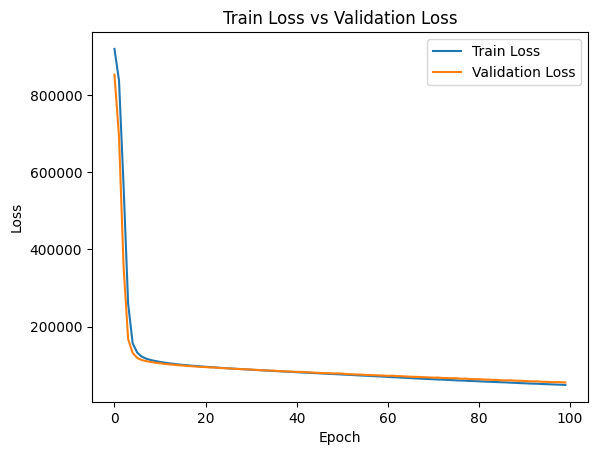

In [94]:
# Baseline의 Train Loss와 Validation Loss 그래프 그리기
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
# 그래프 제목과 범례 설정
plt.title("Train Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Q33. Train Loss는 계속 감소하지만 Validation Loss가 다시 증가한다면 무엇을 의미할까?

**답:**Train Loss는 계속 줄어드는데 Validation Loss가 다시 증가하면 Train 데이터에 너무 맞춰지고 있다는 뜻이다. 이를 과적합이라고 한다.


### Q34. 이 경우 Epoch을 계속 늘리는 것이 좋을까?

**답:**계속 늘리는 것이 좋아진다고 단정 지을수 는 없다.. Validation Loss가 더 이상 좋아지지 않는다면 학습을 멈추는 EarlyStopping 등을 사용할 수 있다.


# STEP 34. Feature Importance 분석

In [95]:
# Feature Importance를 확인할 Random Forest 모델 생성 을 해준다
rf_importance = RandomForestRegressor(random_state=1002)
# 모델 학습
rf_importance.fit(X_train, y_train)

# Feature 이름과 중요도를 표로 만들기 dataframe()을 사용하면 표작성이 가능하다 
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_importance.feature_importances_
})

# 중요도가 높은 순서로 정렬
importance_df = importance_df.sort_values("Importance", ascending=False)

# 상위 15개 확인
importance_df.head(15)

,Feature,Importance
1,temp,0.297932
0,hour,0.198445
2,humidity,0.073377
6,solar,0.066379
32,hour_sin,0.051667
20,functioning_day_No,0.047309
21,functioning_day_Yes,0.043125
5,dew_point,0.021806
33,hour_cos,0.021473
7,rainfall,0.020264


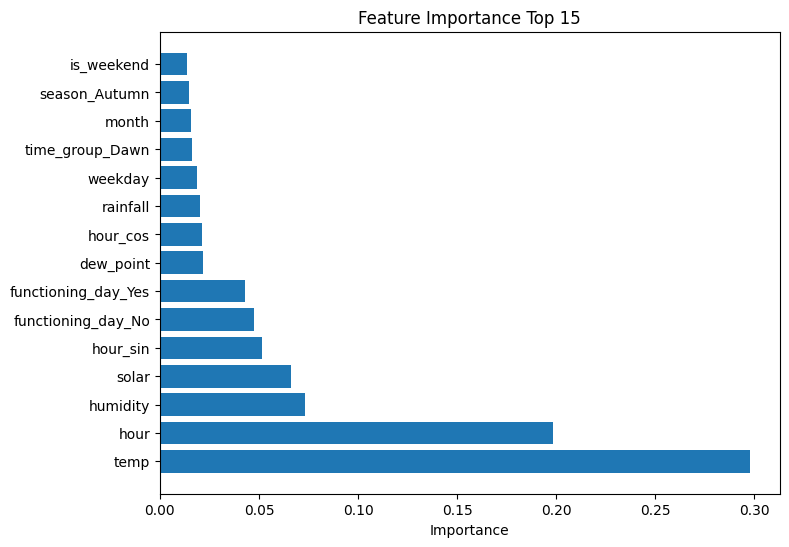

In [96]:
# Feature Importance 상위 15개 그래프로 그려주기 
top15 = importance_df.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Feature Importance Top 15")
plt.xlabel("Importance")
plt.show()

### Q35. DAY 2에서 새로 만든 Feature는 실제 모델에서 중요하게 사용되었는가?

**답:**

In [ ]:
# DAY2에서 새로 만든 Feature만 중요도 확인
new_features = [
    "morning_rush",
    "evening_rush",
    "rain_rush",
    "hour_sin",
    "hour_cos"
]

# 새로 추가한 중요도 출력 해준다
importance_df[importance_df["Feature"].isin(new_features)]

,Feature,Importance
32,hour_sin,0.051667
33,hour_cos,0.021473
30,evening_rush,0.011881
29,morning_rush,0.003505
31,rain_rush,0.000749


### Q36. 새 Feature의 중요도가 낮다면 Feature Engineering이 실패했다고 볼 수 있을까?

**답:**
실패했다고 볼 수는 없다. 이유는  중요도가 낮다고 무조건 실패한 것은 아니다. 다른 Feature와 비슷한 정보를 가지고 있거나 특정 상황에서만 도움이 될 수 있습니다.

# STEP 35. Actual vs Predicted / Residual 분석

## Residual(잔차)이란?

Residual은 **실제값과 예측값의 차이**입니다.

`Residual = Actual - Predicted`

예를 들어 실제 대여량이 1,000인데 모델이 800으로 예측했다면:

`Residual = 1000 - 800 = +200`

반대로 모델이 1,200으로 예측했다면:

`Residual = 1000 - 1200 = -200`

### Q37. Residual이 양수와 음수라는 것은 각각 무엇을 의미할까?

- Residual > 0 :
- Residual < 0 :
- Residual = 0 :

**답:** 
- Residual > 0 : 실제값이 예측값보다 크다. 모델이 실제보다 작게 예측했다.
- Residual < 0 : 실제값이 예측값보다 작다. 모델이 실제보다 크게 예측했다.
- Residual = 0 : 실제값과 예측값이 같다.

### Q38. Residual과 Absolute Error는 무엇이 다를까?

`Residual = Actual - Predicted`

`Absolute Error = |Actual - Predicted|`

**답:**Residual은 실제값 - 예측값 이라서 양수/음수 방향을 알 수 있습니다. Absolute Error는 절댓값을 사용하므로 방향은 없어지고 오차의 크기만 확인할 수 있습니다.


### 최종 후보 모델 선택

STEP 32의 결과를 보고 분석할 모델의 예측값을 `final_pred`에 지정합니다.

In [ ]:
# 예를들어서 Random Forest를 최종 후보 모델로 선택
# 다른 모델이 더 좋게 나왔다면 해당 모델의 예측값으로 수정하면 됨
final_pred = y_pred_rf
# 최종 후보 모델 성능 확인 한다 
evaluate(y_test, final_pred)

{'MAE': 99.49500380517503,
 'RMSE': 175.84936090654548,
 'R2': 0.9245394233383408}

### Q39. 실제값과 예측값은 얼마나 비슷한가?

**답:**아래 그래프에서 점들이 대각선에 가까울수록 실제값과 예측값이 비슷하다고 볼수 있다.


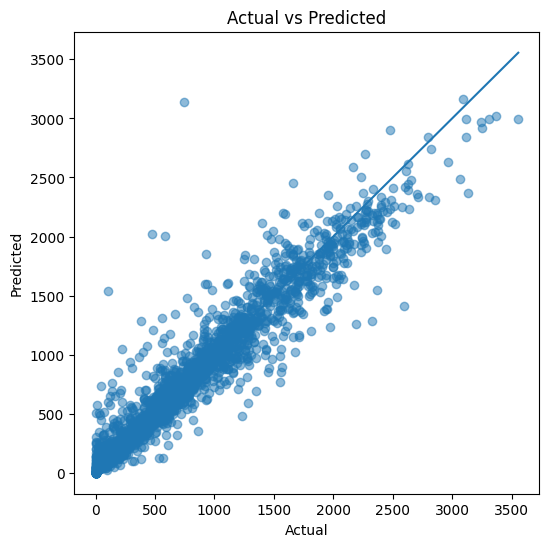

In [101]:
# 실제값과 예측값 비교
plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_pred, alpha=0.5)

# 실제값 = 예측값인 기준선 을 그려준다 
min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())
plt.plot([min_value, max_value], [min_value, max_value])

#그래프 그리기 
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### Q40. Residual 분포를 보고 예측 오차를 해석해보자.

### 생각해보기
- Residual은 0을 중심으로 분포하는가?
- 양수 또는 음수 한쪽으로 치우치는가?
- 큰 Residual이 많이 나타나는가?

**답:**Residual이 0 근처에 많이 모이면 예측이 비교적 잘 된 것이다. 한쪽으로 치우치면 모델이 실제값보다 계속 크게 또는 작게 예측하는 경향이 있을 수 있다. 0에서 아주 먼 값은 틀린 데이터 입니다.


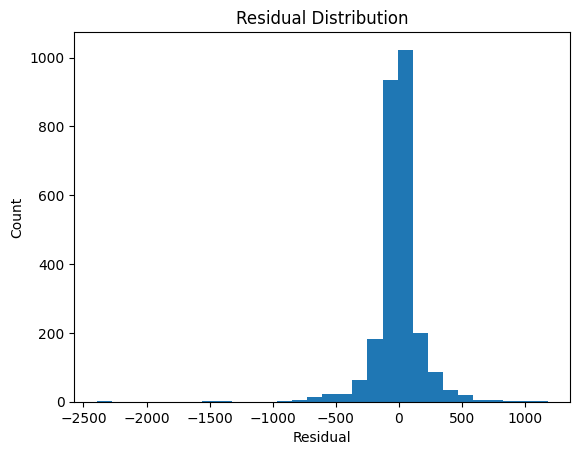

In [103]:
# Residual 계산: 실제값 - 예측값
residual = y_test.values - final_pred

# Residual 분포 확인
plt.hist(residual, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.show()

# STEP 36. 오차가 큰 데이터 분석

In [104]:
# Test 데이터 원본을 복사하여 분석용 데이터 만들기 원본 데이터 손상 안가도록 복사해서 데이터 분석을한다 
error_df = df.loc[X_test.index].copy()

# 실제값을 저장
error_df["actual"] = y_test

# 예측값을 저장
error_df["predicted"] = final_pred

# Residual을 계산
error_df["residual"] = error_df["actual"] - error_df["predicted"]

# Absolute Error을 계산 한다
error_df["abs_error"] = np.abs(error_df["residual"])

# 오차가 큰 데이터부터 확인을 한다 
error_df.sort_values("abs_error", ascending=False).head(20)

,rented,hour,temp,humidity,wind,visibility,dew_point,solar,rainfall,snowfall,...,date,morning_rush,evening_rush,rain_rush,hour_sin,hour_cos,actual,predicted,residual,abs_error
4794,746,18,29.2,35,2.7,1900,12.1,1.27,0.0,0.0,...,2018-06-18,0,1,False,-1.000000,-1.836970e-16,746,3139.21,-2393.21,2393.21
4315,477,19,22.3,71,2.5,1268,16.7,0.14,0.0,0.0,...,2018-05-29,0,1,False,-0.965926,2.588190e-01,477,2022.48,-1545.48,1545.48
3424,103,16,19.1,52,0.9,1583,9.0,0.37,0.0,0.0,...,2018-04-22,0,0,False,-0.866025,-5.000000e-01,103,1540.20,-1437.20,1437.20
6379,582,19,30.0,59,2.2,1970,21.1,0.01,0.0,0.0,...,2018-08-23,0,1,False,-0.965926,2.588190e-01,582,2007.94,-1425.94,1425.94
5155,2598,19,30.4,62,0.9,2000,22.2,0.65,0.1,0.0,...,2018-07-03,0,1,True,-0.965926,2.588190e-01,2598,1415.79,1182.21,1182.21
6872,2329,8,20.9,68,1.3,2000,14.7,0.18,0.0,0.0,...,2018-09-13,1,0,False,0.866025,-5.000000e-01,2329,1288.47,1040.53,1040.53
3783,2191,15,24.6,38,2.1,1478,9.3,1.85,0.0,0.0,...,2018-05-07,0,0,False,-0.707107,-7.071068e-01,2191,1261.52,929.48,929.48
6186,925,18,32.8,63,2.3,1546,24.8,0.89,0.1,0.0,...,2018-08-15,0,1,True,-1.000000,-1.836970e-16,925,1847.76,-922.76,922.76
3422,384,14,20.7,32,1.5,1996,3.3,0.69,0.0,0.0,...,2018-04-22,0,0,False,-0.500000,-8.660254e-01,384,1288.52,-904.52,904.52
4581,225,21,22.4,72,1.5,1816,17.0,0.00,0.1,0.0,...,2018-06-09,0,0,False,-0.707107,7.071068e-01,225,1050.37,-825.37,825.37


### Q41. 모델이 크게 틀린 데이터에는 어떤 공통점이 있는가?

확인해볼 항목:
- 특정 시간대인가?
- 실제 대여량이 매우 높은가?
- 비가 오는가?
- 특정 계절인가?
- 특정 온도 범위인가?

**답:**

### Q42. 시간대별 평균 예측 오차는 어떻게 다른가?

**답:**

# STEP 37. 최종 모델 선정

### 최종 모델

모델:

Feature Engineering:

Encoding:

Scaling:

변경한 Hyperparameter 또는 Network 구조:

MAE:

RMSE:

R²:


### 선정 이유


### 가장 효과가 있었던 실험


### 효과가 거의 없었던 실험


### 모델이 잘 예측하지 못한 데이터


### 추가로 개선한다면

# STEP 38. Wrap-up

### Q43. Feature를 추가했다고 항상 성능이 좋아졌는가?

**답:**

### Q44. Scaler를 변경했을 때 모든 모델의 성능이 달라졌는가?

**답:**

### Q45. Tree 계열 모델은 왜 Scaling의 영향을 거의 받지 않았는가?

**답:**

### Q46. Encoding 방법에 따라 성능이 달라질 수 있는 이유는 무엇인가?

**답:**

### Q47. Hyperparameter를 변경했다고 항상 성능이 개선되었는가?

**답:**

### Q48. Neural Network를 더 넓거나 깊게 만들면 항상 성능이 좋아졌는가?

**답:**

### Q49. 이번 실습에서 모델 성능을 개선하기 위해 시도한 방법을 정리해보자.

1.

2.

3.

4.

5.

**답:**